In [5]:
!pip install torchinfo

In [6]:
#Imports
import torch
from PIL import Image
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.utils.tensorboard import SummaryWriter
import torch.nn.functional as F
from torchinfo import summary
import seaborn as sns
import numpy as np
import pandas as pd
import time, os, random
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import f1_score
from sklearn.metrics import confusion_matrix

In [7]:
# Choose a seed for repeatable results
SEED = 101
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

In [8]:
#Load Data
X = np.load(r"C:\Users\student\Documents\d604\Task1\images\images.npy")
labels = pd.read_csv(r"C:\Users\student\Documents\d604\Task1\images\labels.csv")
#renames the column dataframe
labels.columns = ["label"]

print("X shape: ", X.shape)
print(labels['label'].value_counts().head())

X shape:  (4750, 128, 128, 3)
label
Loose Silky-bent             654
Common Chickweed             611
Scentless Mayweed            516
Small-flowered Cranesbill    496
Fat Hen                      475
Name: count, dtype: int64


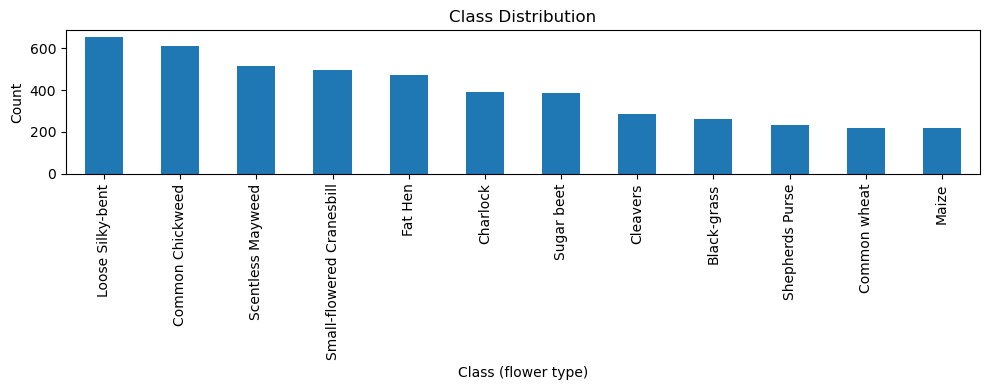

In [9]:
#visualize and count labels
class_counts = labels['label'].value_counts().sort_values(ascending=False)

plt.figure(figsize=(10,4))
class_counts.plot(kind="bar")
plt.title("Class Distribution")
plt.xlabel("Class (flower type)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [10]:
#encode string labels to integers for CrossEntropyLoss
encoder = LabelEncoder()
y = encoder.fit_transform(labels['label'].astype(str).str.strip().values)
num_classes = len(encoder.classes_)
ydf = pd.DataFrame({"id": range(num_classes), "name": encoder.classes_}).head(12)
print("Classes: ", num_classes)
print(ydf)

Classes:  12
    id                       name
0    0                Black-grass
1    1                   Charlock
2    2                   Cleavers
3    3           Common Chickweed
4    4               Common wheat
5    5                    Fat Hen
6    6           Loose Silky-bent
7    7                      Maize
8    8          Scentless Mayweed
9    9            Shepherds Purse
10  10  Small-flowered Cranesbill
11  11                 Sugar beet


In [11]:
ydf.to_csv(r"C:\Users\student\Documents\d604\Task1\encoded_classes")

In [12]:
#Train test spli stratified to keep class balance

#split for training
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.20, stratify=y, random_state=SEED)

#split for validation and testing
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=SEED)

print(f"Counts | Train: {len(X_train)} Val: {len(X_val)} Test: {len(X_test)}")

Counts | Train: 3800 Val: 475 Test: 475


In [13]:
#transform images into NumPy arras into PIL Images, apply data augmentation, convert into PyTorch tensors
img_size = (128,128) # convert to consistent sizes
def np_to_pil(img_np):
    """NumPy to Pil.Image"""
    if img_np.ndim != 3 or 3 not in img_np.shape:
        raise ValueError("Expected 3-channel image")
    if img_np.shape[-1] == 3:
        arr = img_np
    else:
        arr = np.transpose(img_np, (1,2,0))
    return Image.fromarray(arr.astype(np.uint8))
    
def pil_resize(img_pil, size=img_size):
    return img_pil.resize(size, resample=Image.BILINEAR)

def pil_hflip(img_pil, p=0.5):
    return img_pil.transpose(Image.FLIP_LEFT_RIGHT) if random.random() < p else img_pil

def pil_rotate(img_pil, max_deg=20):
    deg = random.uniform(-max_deg, max_deg)
    try:
        return img_pil.rotate(deg, resample=Image.BILINEAR, expand=False, fillcolor=0)
    except TypeError:
        return img_pil.rotate(deg, resample=Image.BILINEAR, expand=False)

def pil_tensor(img_pil):
    """PIL to float32 tensor in CHW, scaled to [0,1]"""
    arr = np.asarray(img_pil).astype(np.float32)
    if arr.max() > 1.5:
        arr = arr/255.0
    arr = np.transpose(arr, (2,0,1))
    return torch.from_numpy(arr) #shape (C,H,W)

def normalize_tensor(x, mean, std):
    """
    x" tensor (C, H,W), mean/std: list length 3
    output is normalized tensor
    """
    mean_t = torch.tensor(mean, dtype=x.dtype, device=x.device)[:, None, None]
    std_t = torch.tensor(std, dtype=x.dtype, device=x.device)[:, None, None]
    return (x - mean_t) / (std_t + 1e-8)
    

In [14]:
# compute the mean/std for training data
Xtrain = X_train.astype(np.float32)
if Xtrain.max() > 1.5:
    Xtrain = Xtrain/255.0

#compute per-chanel stats
if Xtrain.shape[-1] == 3:
    ch_mean = Xtrain.mean(axis=(0,1,2)).tolist()
    ch_std = Xtrain.std(axis=(0,1,2)).tolist()
else:
    ch_mean = Xtrain.mean(axis=(0,2,3)).tolist()
    ch_std = Xtrain.std(axis=(0,2,3)).tolist()

print("mean: ", ch_mean, "std: ", ch_std)

mean:  [0.1402953565120697, 0.16139698028564453, 0.17167621850967407] std:  [0.13350480794906616, 0.14782902598381042, 0.16518037021160126]


In [15]:
class SimpleImageDataset(Dataset):
    def __init__(self, X, y, train, mean, std, do_flip=True, do_rotate=True, max_deg=20):
        self.X, self.y = X, y
        self.train = train
        self.mean, self.std = mean, std
        self.do_flip, self.do_rotate, self.max_deg = do_flip, do_rotate, max_deg

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        #NumPy to PIL
        img = np_to_pil(self.X[idx])

        #Resize
        img = pil_resize(img)

        #Agument on Training data
        if self.train:
            if self.do_flip:
                img = pil_hflip(img, p=0.5)
            if self.do_rotate:
                img = pil_rotate(img, max_deg=self.max_deg)

        #PIL to tensor in CHW [0,1]
        x = pil_tensor(img)
        
        #Normale with Train mean/std
        x = normalize_tensor(x, self.mean, self.std)

        y = int(self.y[idx])
        return x, y
        

In [16]:
# Build loaders
batch_size = 32
dl_train = DataLoader(SimpleImageDataset(X_train, y_train, train=True,  mean=ch_mean, std=ch_std),
                      batch_size=batch_size, shuffle=True,  num_workers=2, pin_memory=True)
dl_val   = DataLoader(SimpleImageDataset(X_val,   y_val,   train=False, mean=ch_mean, std=ch_std),
                      batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
dl_test  = DataLoader(SimpleImageDataset(X_test,  y_test,  train=False, mean=ch_mean, std=ch_std),
                      batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)


In [17]:
from collections import Counter
#test shape of images and label counts
def shape_balance(name, X, y):
    print(f"{name:.6} -> X: {getattr(X, 'shape', 'list of arrays')}, y: {len(y)}")
    print("class balance:", dict(Counter(y)))
shape_balance("train", X_train, y_train)
shape_balance("val", X_val, y_val)
shape_balance("test", X_test, y_test)

train -> X: (3800, 128, 128, 3), y: 3800
class balance: {10: 397, 3: 489, 5: 380, 1: 312, 0: 210, 11: 308, 8: 413, 4: 177, 6: 523, 7: 177, 2: 229, 9: 185}
val -> X: (475, 128, 128, 3), y: 475
class balance: {11: 39, 3: 61, 1: 39, 2: 29, 4: 22, 0: 27, 6: 65, 10: 50, 5: 47, 8: 51, 7: 22, 9: 23}
test -> X: (475, 128, 128, 3), y: 475
class balance: {4: 22, 6: 66, 11: 38, 1: 39, 8: 52, 10: 49, 3: 61, 5: 48, 7: 22, 0: 26, 2: 29, 9: 23}


In [18]:
dl_train = DataLoader(SimpleImageDataset(X_train,y_train, train=True, mean=ch_mean, std=ch_std), batch_size=batch_size, shuffle=True)
dl_val = DataLoader(SimpleImageDataset(X_val,y_val, train=False, mean=ch_mean, std=ch_std), batch_size=batch_size)
dl_test = DataLoader(SimpleImageDataset(X_test,y_test, train=False, mean=ch_mean, std=ch_std), batch_size=batch_size)

In [19]:
xb, yb = next(iter(dl_train))
print(xb.shape, yb.shape)

torch.Size([32, 3, 128, 128]) torch.Size([32])


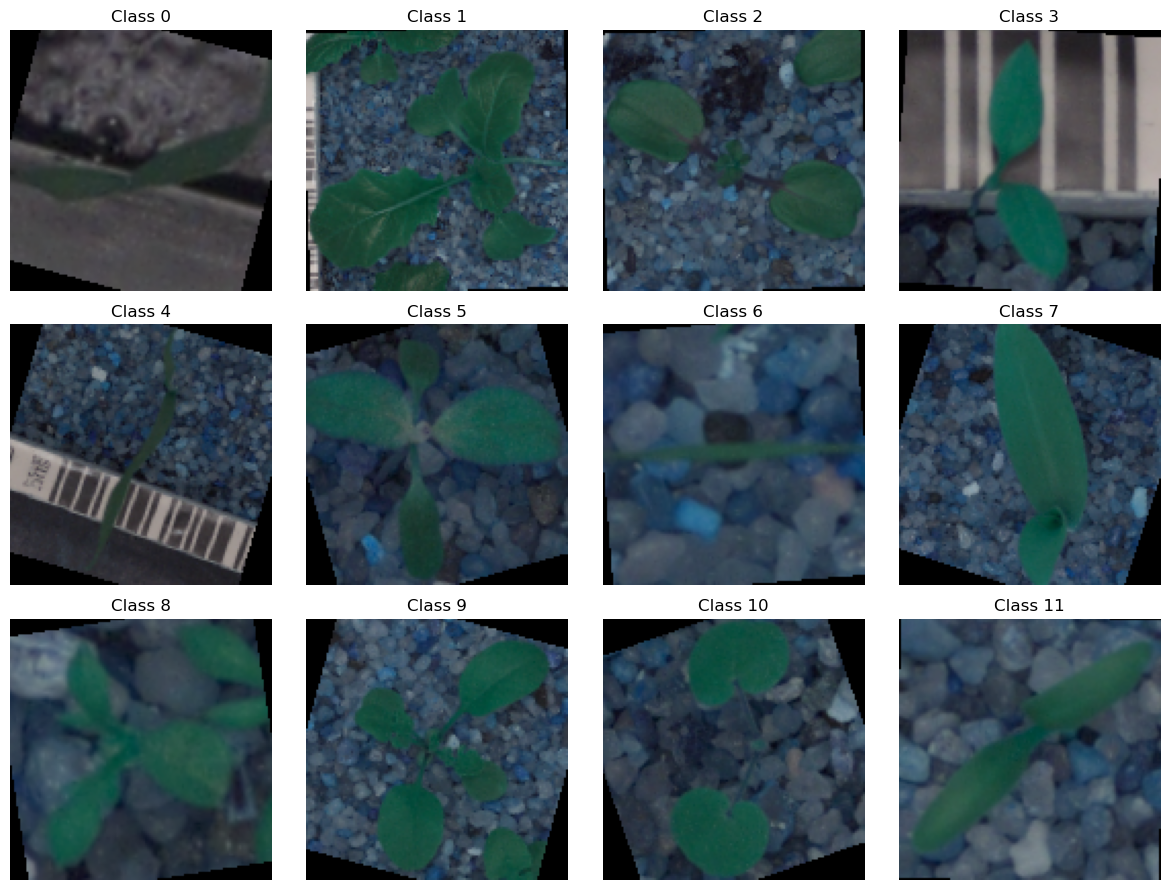

In [20]:
# Display one image per class (0–11)
fig, axes = plt.subplots(3, 4, figsize=(12, 9))

for cls in range(12):
    # Get one batch from the dataloader
    for imgs, labels in dl_train:
        # Find first image matching the current class
        match = (labels == cls).nonzero(as_tuple=True)[0]
        if len(match) > 0:
            img = imgs[match[0]].permute(1, 2, 0)
            img = (img * torch.tensor(ch_std) + torch.tensor(ch_mean)).clamp(0, 1)
            ax = axes[cls // 4, cls % 4]
            ax.imshow(img)
            ax.set_title(f"Class {cls}")
            ax.axis("off")
            break

plt.tight_layout()
plt.show()

In [21]:
dir = r"C:\Users\student\Documents\repo\D604\Task1"
os.makedirs(dir, exist_ok=True)

np.savez_compressed(os.path.join(dir, "train.npz"), X=X_train, y=y_train)
np.savez_compressed(os.path.join(dir, "val.npz"), X=X_val, y=y_val)
np.savez_compressed(os.path.join(dir, "test.npz"), X=X_test, y=y_test)

print("Saved to:", dir)

#save Pytorch tensors
torch.save({"X": torch.from_numpy(X_train), "y": torch.from_numpy(y_train)}, os.path.join(dir, "train.pt"))
torch.save({"X": torch.from_numpy(X_test), "y": torch.from_numpy(y_test)}, os.path.join(dir, "test.pt"))
torch.save({"X": torch.from_numpy(X_val), "y": torch.from_numpy(y_val)}, os.path.join(dir, "val.pt"))


Saved to: C:\Users\student\Documents\repo\D604\Task1


In [22]:
num_classes = 12

class SimpleCNN(nn.Module):
    def __init__(self, num_classes=12):
        super().__init__()
        #128x128 RBG input
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128*16*16, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

model = SimpleCNN(num_classes=num_classes).to("cpu")
        

In [23]:
def count_params(model):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    return total, trainable

#forward to verify shapes
x_dummy = torch.randn(1,3,128,128)
with torch.no_grad():
    y_dummy = model(x_dummy)
print("Output shape (batch, class_logits): ", y_dummy.shape)

total, trainable = count_params(model)
print(f"Total parameters: {total:}")
print(f"Trainable parameters: {trainable:}")
print(model)



Output shape (batch, class_logits):  torch.Size([1, 12])
Total parameters: 8485196
Trainable parameters: 8485196
SimpleCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=32768, out_features=256, bias=True)
    (2): ReLU(inplace=True)
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=256, out_features=12, bias=True)
  )
)


In [24]:
summary(model, input_size=(1,3,128,128))

Layer (type:depth-idx)                   Output Shape              Param #
SimpleCNN                                [1, 12]                   --
├─Sequential: 1-1                        [1, 128, 16, 16]          --
│    └─Conv2d: 2-1                       [1, 32, 128, 128]         896
│    └─ReLU: 2-2                         [1, 32, 128, 128]         --
│    └─MaxPool2d: 2-3                    [1, 32, 64, 64]           --
│    └─Conv2d: 2-4                       [1, 64, 64, 64]           18,496
│    └─ReLU: 2-5                         [1, 64, 64, 64]           --
│    └─MaxPool2d: 2-6                    [1, 64, 32, 32]           --
│    └─Conv2d: 2-7                       [1, 128, 32, 32]          73,856
│    └─ReLU: 2-8                         [1, 128, 32, 32]          --
│    └─MaxPool2d: 2-9                    [1, 128, 16, 16]          --
├─Sequential: 1-2                        [1, 12]                   --
│    └─Flatten: 2-10                     [1, 32768]                --
│    └

In [25]:
criterion = nn.CrossEntropyLoss()
#Adam adapts learning rates for parameters
optimizer = optim.Adam(model.parameters(), lr=3e-4, weight_decay=1e-4)

In [26]:
num_epochs = 10
patience   = 3
best_val   = float('inf')
best_state = None
wait       = 0

train_losses, val_losses = [], []
train_accs,  val_accs    = [], []

for epoch in range(num_epochs):
    # ---- TRAIN ----
    model.train()
    total_loss, total_correct, total_samples = 0.0, 0, 0
    for xb, yb in dl_train:
        optimizer.zero_grad()
        logits = model(xb)
        loss   = criterion(logits, yb)
        loss.backward()
        optimizer.step()

        bs = yb.size(0)
        total_loss    += loss.item() * bs
        total_correct += (logits.argmax(1) == yb).sum().item()
        total_samples += bs

    tr_loss = total_loss / total_samples
    tr_acc  = total_correct / total_samples

    # ---- VALIDATE ----
    model.eval()
    v_loss_sum, v_correct, v_samples = 0.0, 0, 0
    with torch.no_grad():
        for xb, yb in dl_val:
            logits = model(xb)
            loss   = criterion(logits, yb)
            bs = yb.size(0)
            v_loss_sum += loss.item() * bs
            v_correct  += (logits.argmax(1) == yb).sum().item()
            v_samples  += bs

    va_loss = v_loss_sum / v_samples
    va_acc  = v_correct  / v_samples

    train_losses.append(tr_loss); val_losses.append(va_loss)
    train_accs.append(tr_acc);    val_accs.append(va_acc)

    print(f"Epoch {epoch+1:02d}/{num_epochs} | "
          f"train_loss {tr_loss:.3f} acc {tr_acc:.3f} | "
          f"val_loss {va_loss:.3f} acc {va_acc:.3f}")

    # ---- early stopping ----
    if va_loss < best_val - 1e-4:
        best_val = va_loss
        best_state = {k: v.clone() for k, v in model.state_dict().items()}
        wait = 0
    else:
        wait += 1
        if wait >= patience:
            print(f"Early stopping at epoch {epoch+1}. Best val_loss={best_val:.3f}")
            break

if best_state is not None:
    model.load_state_dict(best_state)

Epoch 01/10 | train_loss 1.958 acc 0.332 | val_loss 1.378 acc 0.541
Epoch 02/10 | train_loss 1.256 acc 0.571 | val_loss 1.028 acc 0.642
Epoch 03/10 | train_loss 1.000 acc 0.663 | val_loss 0.834 acc 0.735
Epoch 04/10 | train_loss 0.852 acc 0.717 | val_loss 0.781 acc 0.716
Epoch 05/10 | train_loss 0.746 acc 0.757 | val_loss 0.656 acc 0.787
Epoch 06/10 | train_loss 0.637 acc 0.789 | val_loss 0.548 acc 0.800
Epoch 07/10 | train_loss 0.545 acc 0.817 | val_loss 0.513 acc 0.829
Epoch 08/10 | train_loss 0.506 acc 0.824 | val_loss 0.482 acc 0.832
Epoch 09/10 | train_loss 0.466 acc 0.846 | val_loss 0.450 acc 0.863
Epoch 10/10 | train_loss 0.425 acc 0.853 | val_loss 0.404 acc 0.872


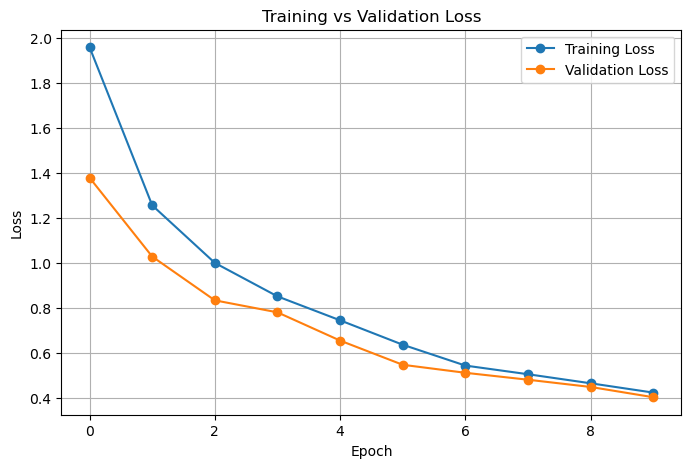

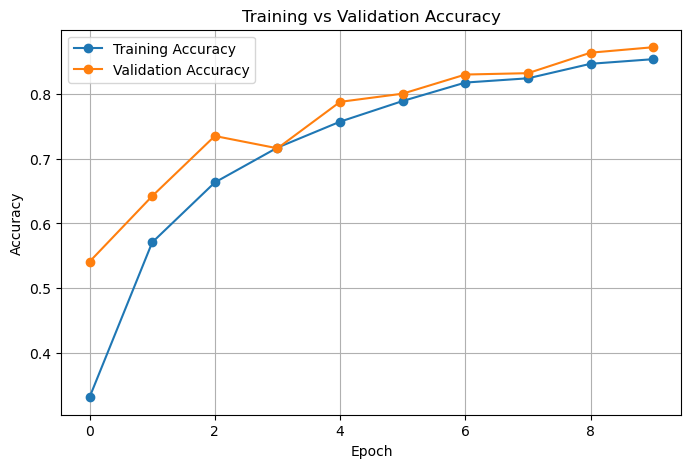

In [27]:
plt.figure(figsize=(8,5))
plt.plot(train_losses, label='Training Loss', marker='o')
plt.plot(val_losses, label='Validation Loss', marker='o')
plt.title('Training vs Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(8,5))
plt.plot(train_accs, label='Training Accuracy', marker='o')
plt.plot(val_accs, label='Validation Accuracy', marker='o')
plt.title('Training vs Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.show() 


In [28]:
model.eval()
y_true, y_pred = [], []
with torch.no_grad():
    for xb, yb in dl_val:
        logits = model(xb)
        y_true.extend(yb.numpy().tolist())
        y_pred.extend(logits.argmax(1).numpy().tolist())
val_f1 = f1_score(y_true, y_pred, average='macro')
print(f"Final train | loss={train_losses[-1]:.3f}. acc={train_accs[-1]:.3f}")
print(f"Final val | loss={val_losses[-1]:.3f}, acc={val_accs[-1]:.3f}")
print(f"Final val F1 (macro): {val_f1: .3f}")

Final train | loss=0.425. acc=0.853
Final val | loss=0.404, acc=0.872
Final val F1 (macro):  0.851


Confusion matrix shape: (12, 12)
[[ 9  0  0  0  0  0 18  0  0  0  0  0]
 [ 0 37  0  0  0  1  0  0  0  1  0  0]
 [ 0  0 28  0  1  0  0  0  0  0  0  0]
 [ 0  0  0 55  0  0  0  0  4  1  1  0]
 [ 0  0  1  0 17  0  4  0  0  0  0  0]
 [ 1  0  0  0  1 43  1  0  0  0  1  0]
 [ 2  0  0  1  0  0 62  0  0  0  0  0]
 [ 0  0  1  0  0  0  0 17  3  0  1  0]
 [ 1  1  0  0  0  0  2  0 46  1  0  0]
 [ 0  0  1  0  0  0  0  0  4 18  0  0]
 [ 0  0  0  0  0  0  0  0  0  0 48  2]
 [ 0  0  0  1  1  0  0  1  1  0  1 34]]


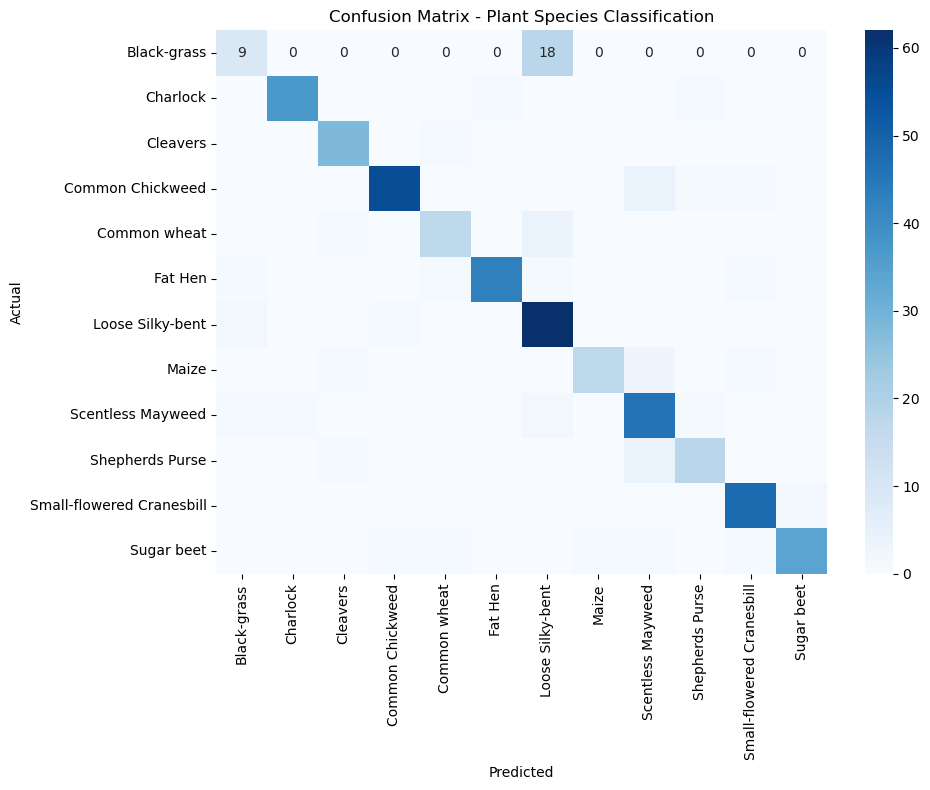

In [29]:
# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)

print("Confusion matrix shape:", cm.shape)
print(cm)

plt.figure(figsize=(10,8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=encoder.classes_,
            yticklabels=encoder.classes_,)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Plant Species Classification')
plt.tight_layout()
plt.show()


In [30]:
#testing model
model.eval()
y_true, y_pred = [], []
with torch.no_grad():
    for xb, yb in dl_test:
        logits = model(xb)
        y_true.extend(yb.numpy().tolist())
        y_pred.extend(logits.argmax(1).numpy().tolist())

In [31]:
torch.save(model.state_dict(), "cnn_flower_model.pth")
# to reload later
model.load_state_dict(torch.load("cnn_flower_model.pth"))
model.eval()

SimpleCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=32768, out_features=256, bias=True)
    (2): ReLU(inplace=True)
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=256, out_features=12, bias=True)
  )
)